<a href="https://colab.research.google.com/github/youkjang/noaa-gefs-data-access/blob/main/nootebooks/open_gefs_files_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Practice: NOAA Global Ensemble Forecast System (GEFS)

##How to Open GEFS files from Amazon S3

Packages for GEFS files
- ecodes: provide the GRIB-decoding engine
- cfgrib: xarray open GRIB files
- s3fs: access files stored in Amazon S3
- fsspec: A general filesystem interface used by packages like xarray, s3fs, and others to read files from local disks, cloud storage, URLs, etc.


##1. Install packages

In [14]:
!pip -q install "eccodes>=2.37.0" cfgrib s3fs fsspec

##2.Define one GEFS file path

In [15]:
import s3fs
from pathlib import Path

init_date = "20260501"   # YYYYMMDD
cycle = "00"             # 00, 06, 12, 18
member = "c00"           # control member
fhr = 0                  # forecast hour

bucket = "noaa-gefs-pds"
s3_key = (
    f"{bucket}/gefs.{init_date}/{cycle}/atmos/pgrb2ap5/"
    f"ge{member}.t{cycle}z.pgrb2a.0p50.f{fhr:03d}"
)

s3_key

'noaa-gefs-pds/gefs.20260501/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f000'

##3. Download the GRIB2 file locally

In [16]:
fs = s3fs.S3FileSystem(anon=True)

cache_dir = Path("/content/gefs_cache")
cache_dir.mkdir(exist_ok=True)

local_file = cache_dir / Path(s3_key).name

if not local_file.exists():
    fs.get(s3_key, str(local_file))

local_file

PosixPath('/content/gefs_cache/gec00.t00z.pgrb2a.0p50.f000')

##4. Open 2m temperature

In [17]:
import xarray as xr

ds_t2m = xr.open_dataset(
    local_file,
    engine="cfgrib",
    backend_kwargs={
        "filter_by_keys": {
            "typeOfLevel": "heightAboveGround",
            "level": 2
        },
        "indexpath": ""
    }
)

ds_t2m

<xarray.Dataset> Size: 2MB
Dimensions:            (latitude: 361, longitude: 720)
Coordinates:
  * latitude           (latitude) float64 3kB 90.0 89.5 89.0 ... -89.5 -90.0
  * longitude          (longitude) float64 6kB 0.0 0.5 1.0 ... 358.5 359.0 359.5
    number             int64 8B ...
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
    valid_time         datetime64[ns] 8B ...
Data variables:
    t2m                (latitude, longitude) float32 1MB ...
    r2                 (latitude, longitude) float32 1MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-05-19T17:45 GRIB to CDM+CF via cfgrib-0.9.1...

In [18]:
list(ds_t2m.data_vars)

['t2m', 'r2']

In [19]:
t2m = ds_t2m["t2m"]

##5. Subset to the U.S. region

In [20]:
t2m = t2m.assign_coords(
    longitude=((t2m.longitude + 180) % 360) - 180
).sortby("longitude")

# CONUS box
t2m_us = t2m.sel(
    longitude=slice(-125, -66),
    latitude=slice(50, 24)
)

t2m_us

<xarray.DataArray 't2m' (latitude: 53, longitude: 119)> Size: 25kB
[6307 values with dtype=float32]
Coordinates:
  * latitude           (latitude) float64 424B 50.0 49.5 49.0 ... 25.0 24.5 24.0
  * longitude          (longitude) float64 952B -125.0 -124.5 ... -66.5 -66.0
    number             int64 8B ...
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
    valid_time         datetime64[ns] 8B ...
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            cf
    GRIB_numberOfPoints:                      259920
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           2t
    GRIB_totalNumber:                         30
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            air_temperature

##6. Quick plot

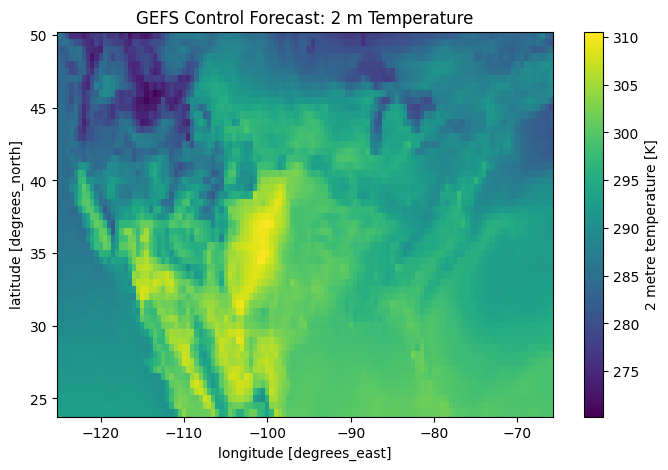

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
t2m_us.plot()
plt.title("GEFS Control Forecast: 2 m Temperature")
plt.show()

## Note on AI Assistance

ChatGPT was used as a coding assistant for drafting and debugging portions of the Python workflow.
All scientific decisions, code review, testing, and interpretation were performed by me.